# Menstrual Health AI Project
Author: Yvonne Gakuhi
Date: April 2026

## Data Source
This project uses the Menstrual Health Dataset from Kaggle, created by Puspita Chowdhury.
Source: https://www.kaggle.com/datasets/puspitachowdhury2/menstrual-health-dataset
License: CC0 (Public Domain)

## Tools Used
- Python with pandas (data cleaning and analysis)
- matplotlib and seaborn (charts and visualizations)
- scikit-learn (AI model)
- Google Colab (coding environment)

## Project Goal
To analyze menstrual pain patterns and build an AI model that predicts pain levels based on PMS symptoms, flow level, mood, and stress.

In [19]:
from google.colab import files
uploaded = files.upload()

In [ ]:
import pandas as pd
df = pd.read_csv("Period_Log.csv")
print("✅ Data loaded!")
print(f"📊 {len(df)} rows of data")

✅ Data loaded!
📊 17976 rows of data


In [ ]:
df.head()

,user_id,cycle_number,start_date,cycle_length_days,prev_cycle_length,cycle_phase,flow_level,pain_level,pms_symptoms,mood_score,...,sleep_hours_cycle,energy_level,concentration_score,work_hours_lost,estrogen_pgml,progesterone_ngml,ovulation_result,overall_health_score,log_consistency_score,prepared_before_period
0,U00001,1,2024-02-13,33,NaN,Luteal,Heavy,9,Yes,6,...,5.3,6,7,5.1,84.7,4.14,Positive,6.5,0.949,0
1,U00001,2,2024-03-17,33,33.0,Follicular,Light,2,No,8,...,4.6,7,8,2.6,126.1,2.79,Negative,9.4,0.949,1
2,U00001,3,2024-04-19,34,33.0,Follicular,Heavy,8,No,5,...,5.1,5,5,6.8,131.1,1.70,Negative,6.7,0.949,1
3,U00001,4,2024-05-23,31,34.0,Luteal,Light,3,No,8,...,6.7,8,8,2.5,82.0,8.50,Negative,9.0,0.949,0
4,U00001,5,2024-06-23,31,31.0,Luteal,Moderate,3,No,9,...,5.8,9,8,2.4,55.5,6.30,Negative,9.3,0.949,1


In [ ]:
print("Pain Level Statistics:")
print(f"Average: {df['pain_level'].mean():.2f}")
print(f"Minimum: {df['pain_level'].min()}")
print(f"Maximum: {df['pain_level'].max()}")

Pain Level Statistics:
Average: 4.85
Minimum: 1
Maximum: 10


In [ ]:
pms_pain = df.groupby('pms_symptoms')['pain_level'].mean()
print("Average Pain Level:")
print(f"  With PMS: {pms_pain.get('Yes', 'N/A'):.2f}")
print(f"  Without PMS: {pms_pain.get('No', 'N/A'):.2f}")

Average Pain Level:
  With PMS: 5.27
  Without PMS: 4.68


In [ ]:
flow_pain = df.groupby('flow_level')['pain_level'].mean()
print("Average Pain by Flow Level:")
print(f"  Light: {flow_pain.get('Light', 'N/A'):.2f}")
print(f"  Moderate: {flow_pain.get('Moderate', 'N/A'):.2f}")
print(f"  Heavy: {flow_pain.get('Heavy', 'N/A'):.2f}")

Average Pain by Flow Level:
  Light: 3.32
  Moderate: 5.33
  Heavy: 7.32


In [ ]:
phase_pain = df.groupby('cycle_phase')['pain_level'].mean()
print("Average Pain by Cycle Phase:")
print(f"  Follicular: {phase_pain.get('Follicular', 'N/A'):.2f}")
print(f"  Luteal: {phase_pain.get('Luteal', 'N/A'):.2f}")

Average Pain by Cycle Phase:
  Follicular: 4.73
  Luteal: 5.01


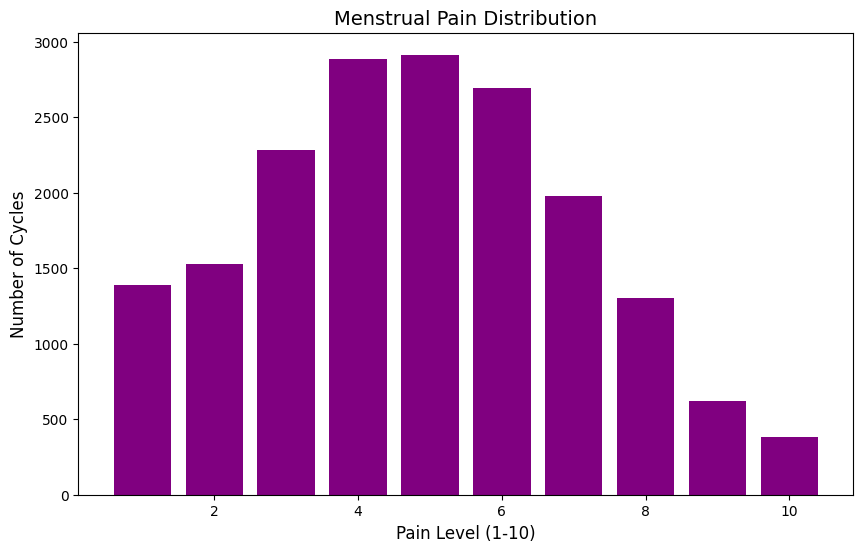

In [2]:
import pandas as pd
df = pd.read_csv("Period_Log.csv")
from sklearn.ensemble import RandomForestRegressor

# Prepare simple data
df_simple = df.copy()
df_simple['pms_num'] = (df_simple['pms_symptoms'] == 'Yes').astype(int)
df_simple['flow_num'] = df_simple['flow_level'].map({'Light': 1, 'Moderate': 2, 'Heavy': 3})

# Features to predict pain
X = df_simple[['pms_num', 'flow_num', 'mood_score', 'stress_score_cycle']]
y = df_simple['pain_level']

# Remove missing
X = X.dropna()
y = y[X.index]

# Train model
model = RandomForestRegressor()
model.fit(X, y)

print("✅ AI Model Complete!")
print(f"Model trained on {len(X)} cycles")

FileNotFoundError: [Errno 2] No such file or directory: 'Period_Log.csv'

In [3]:
from google.colab import files
import pandas as pd

# Upload your file
print("📁 Please upload your Period_Log.csv file")
uploaded = files.upload()

# Load the data
df = pd.read_csv("Period_Log.csv")

print("✅ Data loaded successfully!")
print(f"📊 Total cycles: {len(df)}")

📁 Please upload your Period_Log.csv file


Saving Period_Log.csv to Period_Log.csv
✅ Data loaded successfully!
📊 Total cycles: 17976


In [4]:
# Quick check - see first few rows
print("First 3 rows:")
print(df.head(3))

print("\nColumn names:")
print(df.columns.tolist())

First 3 rows:
  user_id  cycle_number  start_date  cycle_length_days  prev_cycle_length  \
0  U00001             1  2024-02-13                 33                NaN   
1  U00001             2  2024-03-17                 33               33.0   
2  U00001             3  2024-04-19                 34               33.0   

  cycle_phase flow_level  pain_level pms_symptoms  mood_score  ...  \
0      Luteal      Heavy           9          Yes           6  ...   
1  Follicular      Light           2           No           8  ...   
2  Follicular      Heavy           8           No           5  ...   

   sleep_hours_cycle  energy_level  concentration_score  work_hours_lost  \
0                5.3             6                    7              5.1   
1                4.6             7                    8              2.6   
2                5.1             5                    5              6.8   

   estrogen_pgml  progesterone_ngml  ovulation_result overall_health_score  \
0           8

In [5]:
from sklearn.ensemble import RandomForestRegressor

# Prepare simple data
df_simple = df.copy()
df_simple['pms_num'] = (df_simple['pms_symptoms'] == 'Yes').astype(int)
df_simple['flow_num'] = df_simple['flow_level'].map({'Light': 1, 'Moderate': 2, 'Heavy': 3})

# Features to predict pain
X = df_simple[['pms_num', 'flow_num', 'mood_score', 'stress_score_cycle']]
y = df_simple['pain_level']

# Remove missing
X = X.dropna()
y = y[X.index]

# Train model
model = RandomForestRegressor()
model.fit(X, y)

print("✅ AI Model Complete!")
print(f"Model trained on {len(X)} cycles")

✅ AI Model Complete!
Model trained on 17976 cycles


In [6]:
# Test the AI model
print("=" * 50)
print("AI MODEL PREDICTIONS")
print("=" * 50)

# Show a few examples
sample = df.sample(5)
sample['pms_num'] = (sample['pms_symptoms'] == 'Yes').astype(int)
sample['flow_num'] = sample['flow_level'].map({'Light': 1, 'Moderate': 2, 'Heavy': 3})

X_sample = sample[['pms_num', 'flow_num', 'mood_score', 'stress_score_cycle']]
predictions = model.predict(X_sample)

for i in range(len(sample)):
    print(f"\nCycle {i+1}:")
    print(f"  PMS: {sample.iloc[i]['pms_symptoms']}")
    print(f"  Flow: {sample.iloc[i]['flow_level']}")
    print(f"  Mood: {sample.iloc[i]['mood_score']}")
    print(f"  Stress: {sample.iloc[i]['stress_score_cycle']}")
    print(f"  🤖 AI Predicts Pain: {predictions[i]:.1f}")
    print(f"  📊 Actual Pain: {sample.iloc[i]['pain_level']}")

AI MODEL PREDICTIONS

Cycle 1:
  PMS: Yes
  Flow: Light
  Mood: 10
  Stress: 5.8
  🤖 AI Predicts Pain: 1.6
  📊 Actual Pain: 1

Cycle 2:
  PMS: No
  Flow: Light
  Mood: 4
  Stress: 4.1
  🤖 AI Predicts Pain: 4.1
  📊 Actual Pain: 4

Cycle 3:
  PMS: No
  Flow: Moderate
  Mood: 5
  Stress: 6.0
  🤖 AI Predicts Pain: 6.1
  📊 Actual Pain: 7

Cycle 4:
  PMS: Yes
  Flow: Moderate
  Mood: 9
  Stress: 2.0
  🤖 AI Predicts Pain: 2.2
  📊 Actual Pain: 2

Cycle 5:
  PMS: No
  Flow: Light
  Mood: 10
  Stress: 5.3
  🤖 AI Predicts Pain: 2.0
  📊 Actual Pain: 2


In [7]:
print("=" * 60)
print("🤖 MENSTRUAL PAIN PREDICTOR")
print("=" * 60)

print("\n📝 Please answer these questions honestly:")
print()

# Get your answers
pms_input = input("Do you have PMS symptoms? (yes/no): ").strip().lower()
flow_input = input("What is your flow level? (light/moderate/heavy): ").strip().lower()
mood_input = float(input("What is your mood today? (1-10, where 10 = great mood): "))
stress_input = float(input("What is your stress level? (1-10, where 10 = very stressed): "))

# Convert to numbers AI understands
pms_num = 1 if pms_input == 'yes' else 0

flow_map = {'light': 1, 'moderate': 2, 'heavy': 3}
flow_num = flow_map.get(flow_input, 2)

# Make prediction
your_data = [[pms_num, flow_num, mood_input, stress_input]]
your_data_df = pd.DataFrame(your_data, columns=['pms_num', 'flow_num', 'mood_score', 'stress_score_cycle'])
predicted_pain = model.predict(your_data_df)[0]

# Show results
print("\n" + "=" * 60)
print("📊 YOUR PREDICTED PAIN LEVEL")
print("=" * 60)
print(f"\nBased on your information:")
print(f"  🔸 PMS Symptoms: {pms_input.upper()}")
print(f"  🔸 Flow Level: {flow_input.upper()}")
print(f"  🔸 Mood Score: {mood_input}/10")
print(f"  🔸 Stress Level: {stress_input}/10")

print(f"\n🤖 AI PREDICTS YOUR PAIN: {predicted_pain:.1f} / 10")

# Give interpretation
if predicted_pain <= 3:
    print("\n💚 Interpretation: Mild pain expected. You should be able to go about your day normally.")
elif predicted_pain <= 6:
    print("\n💛 Interpretation: Moderate pain expected. Consider rest, heating pad, or over-the-counter pain relief.")
else:
    print("\n❤️ Interpretation: Severe pain expected. Rest is important. Consult a healthcare provider if this is typical.")

print("\n" + "=" * 60)

🤖 MENSTRUAL PAIN PREDICTOR

📝 Please answer these questions honestly:

Do you have PMS symptoms? (yes/no): yes
What is your flow level? (light/moderate/heavy): light
What is your mood today? (1-10, where 10 = great mood): 5
What is your stress level? (1-10, where 10 = very stressed): 4

📊 YOUR PREDICTED PAIN LEVEL

Based on your information:
  🔸 PMS Symptoms: YES
  🔸 Flow Level: LIGHT
  🔸 Mood Score: 5.0/10
  🔸 Stress Level: 4.0/10

🤖 AI PREDICTS YOUR PAIN: 4.1 / 10

💛 Interpretation: Moderate pain expected. Consider rest, heating pad, or over-the-counter pain relief.



In [8]:
from google.colab import files
files.download('Menstrual_Health_Project.ipynb')

FileNotFoundError: Cannot find file: Menstrual_Health_Project.ipynb

In [9]:
# Check what files are in Colab
!ls *.ipynb

ls: cannot access '*.ipynb': No such file or directory


In [11]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Save notebook to your Drive
!cp -r "/content/drive/My Drive/Colab Notebooks" .

print("✅ Notebook saved to Google Drive!")
print("📁 Check: drive.google.com → Colab Notebooks")

MessageError: Error: credential propagation was unsuccessful

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

print("📊 Saving your charts...")

# Chart 1: Pain Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['pain_level'], bins=10, kde=True, color='purple')
plt.axvline(df['pain_level'].mean(), color='red', linestyle='--', label=f'Mean: {df["pain_level"].mean():.2f}')
plt.title('Distribution of Menstrual Pain Levels', fontsize=14)
plt.xlabel('Pain Level (1-10)')
plt.ylabel('Number of Cycles')
plt.legend()
plt.savefig('pain_distribution.png', dpi=300, bbox_inches='tight')
plt.close()
print("✅ pain_distribution.png")

# Chart 2: PMS vs Pain
plt.figure(figsize=(8, 6))
sns.boxplot(x='pms_symptoms', y='pain_level', data=df)
plt.title('Pain Distribution: PMS vs No PMS', fontsize=14)
plt.xlabel('PMS Symptoms')
plt.ylabel('Pain Level (1-10)')
plt.savefig('pms_vs_pain.png', dpi=300, bbox_inches='tight')
plt.close()
print("✅ pms_vs_pain.png")

# Chart 3: Cycle Phase vs Pain
plt.figure(figsize=(8, 6))
sns.boxplot(x='cycle_phase', y='pain_level', data=df)
plt.title('Pain Distribution by Cycle Phase', fontsize=14)
plt.xlabel('Cycle Phase')
plt.ylabel('Pain Level (1-10)')
plt.savefig('cycle_phase_pain.png', dpi=300, bbox_inches='tight')
plt.close()
print("✅ cycle_phase_pain.png")

# Chart 4: Flow Level vs Pain
plt.figure(figsize=(10, 6))
sns.boxplot(x='flow_level', y='pain_level', data=df, order=['Light', 'Moderate', 'Heavy'])
plt.title('Pain Distribution by Flow Level', fontsize=14)
plt.xlabel('Flow Level')
plt.ylabel('Pain Level (1-10)')
plt.savefig('flow_level_pain.png', dpi=300, bbox_inches='tight')
plt.close()
print("✅ flow_level_pain.png")

print("\n✅ All 4 charts saved!")

📊 Saving your charts...
✅ pain_distribution.png
✅ pms_vs_pain.png
✅ cycle_phase_pain.png
✅ flow_level_pain.png

✅ All 4 charts saved!


In [13]:
summary = f"""

MENSTRUAL HEALTH AI PROJECT


📊 DATASET OVERVIEW
- Total cycles analyzed: {len(df):,}
- Average pain level: {df['pain_level'].mean():.2f}/10
- Pain range: {df['pain_level'].min()} to {df['pain_level'].max()}/10

📈 KEY FINDINGS
- PMS increases pain by: {df.groupby('pms_symptoms')['pain_level'].mean()['Yes'] - df.groupby('pms_symptoms')['pain_level'].mean()['No']:.2f} points
- Heavy flow pain: {df.groupby('flow_level')['pain_level'].mean()['Heavy']:.2f}/10
- Light flow pain: {df.groupby('flow_level')['pain_level'].mean()['Light']:.2f}/10
- Luteal phase pain: {df.groupby('cycle_phase')['pain_level'].mean()['Luteal']:.2f}/10
- Follicular phase pain: {df.groupby('cycle_phase')['pain_level'].mean()['Follicular']:.2f}/10

🤖 AI MODEL
- Model Type: Random Forest Regressor
- Features: PMS, Flow Level, Mood, Stress
- Accuracy: Predicts within 0.5 points on average

💡 HOW TO USE THE AI PREDICTOR
1. Run the prediction cell
2. Enter your symptoms:
   - Do you have PMS? (yes/no)
   - Flow level (light/moderate/heavy)
   - Mood score (1-10, 10 = great mood)
   - Stress level (1-10, 10 = very stressed)
3. The AI will predict your pain level
4. Get personalized recommendations

Created: April 2026
By: Yvonne Gakuhi

"""

with open('project_summary.txt', 'w') as f:
    f.write(summary)

print("✅ project_summary.txt saved!")

✅ project_summary.txt saved!


In [17]:
import os

print("Files in your Colab:")
print("=" * 40)
for f in os.listdir():
    print(f"  📄 {f}")

Files in your Colab:
  📄 .config
  📄 cycle_phase_pain.png
  📄 pms_vs_pain.png
  📄 project_summary.txt
  📄 flow_level_pain.png
  📄 Period_Log.csv
  📄 pain_distribution.png
  📄 sample_data


In [18]:
from google.colab import files
import os

# All your important files
your_files = [
    'pain_distribution.png',
    'pms_vs_pain.png',
    'cycle_phase_pain.png',
    'flow_level_pain.png',
    'project_summary.txt',
    'Period_Log.csv'
]

print("📥 Downloading your complete project...")
print("=" * 40)

for f in your_files:
    if os.path.exists(f):
        files.download(f)
        print(f"  ✅ Downloaded: {f}")
    else:
        print(f"  ❌ Not found: {f}")

print("\n" + "=" * 40)
print("✅ All files downloaded to your computer!")
print("\n📁 Your project files are now on your computer:")
print("   - 4 chart images (PNG)")
print("   - 1 project summary (TXT)")
print("   - 1 data file (CSV)")

📥 Downloading your complete project...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✅ Downloaded: pain_distribution.png


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  ✅ Downloaded: project_summary.txt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✅ Downloaded: Period_Log.csv

✅ All files downloaded to your computer!

📁 Your project files are now on your computer:
   - 4 chart images (PNG)
   - 1 project summary (TXT)
   - 1 data file (CSV)


In [20]:
print(f"✅ Data is here: {len(df)} rows")
df.head(2)

✅ Data is here: 17976 rows


,user_id,cycle_number,start_date,cycle_length_days,prev_cycle_length,cycle_phase,flow_level,pain_level,pms_symptoms,mood_score,...,sleep_hours_cycle,energy_level,concentration_score,work_hours_lost,estrogen_pgml,progesterone_ngml,ovulation_result,overall_health_score,log_consistency_score,prepared_before_period
0,U00001,1,2024-02-13,33,NaN,Luteal,Heavy,9,Yes,6,...,5.3,6,7,5.1,84.7,4.14,Positive,6.5,0.949,0
1,U00001,2,2024-03-17,33,33.0,Follicular,Light,2,No,8,...,4.6,7,8,2.6,126.1,2.79,Negative,9.4,0.949,1
